# Figure 6 - Nongenic/Antisense Transcripts Panel

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.sgd import read_nondubious_genes_dataset
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genes = read_nondubious_genes_dataset()
gene = genes[genes['gene'] == 'HTA1'].iloc[0]

genome_deconv_analysis = GenomeDeconvolutionAnalysis(
    'output/draft4_run/', 
    'output/draft4_run/chromatin_deconvolution/deconvolution_data/')
span = gene.start-2000, gene.stop+2000
loaded_data = genome_deconv_analysis.load_mnase_span(gene.chr, span)


In [4]:
from src.transcript_boundary_caller import TranscriptBoundaryCaller
from src.timer import Timer

caller = TranscriptBoundaryCaller(output_directory='output/draft4_run/')
caller.set_chrom_span(gene.chr, span)

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 4
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr4.h5, crick_rna_seq_pileup_rep1_chr4.h5
Shape: (16, 1531933) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr4.h5, crick_rna_seq_pileup_rep2_chr4.h5
Shape: (14, 1531933) (timepoints x positions)


In [5]:
from src.orf_plotter import load_default_orf_plotter
from src.rna_pileup_plotter import RNASeqPileupPlotter
from src.combined_chromatin_model import CombinedChromatinModel
from src.config import load_default_chrom_configs

outdir = 'output/draft4_run/'
config1, config2 = load_default_chrom_configs()
orf_plotter = load_default_orf_plotter()
rna_plotter = RNASeqPileupPlotter(outdir)
combined_model = CombinedChromatinModel(config1=config1, config2=config2)    

In [6]:
caller.call_boundaries_both_strands()

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 4
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr4.h5, crick_rna_seq_pileup_rep1_chr4.h5
Shape: (16, 1531933) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr4.h5, crick_rna_seq_pileup_rep2_chr4.h5
Shape: (14, 1531933) (timepoints x positions)
Loading chromosome reads: 4
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupan

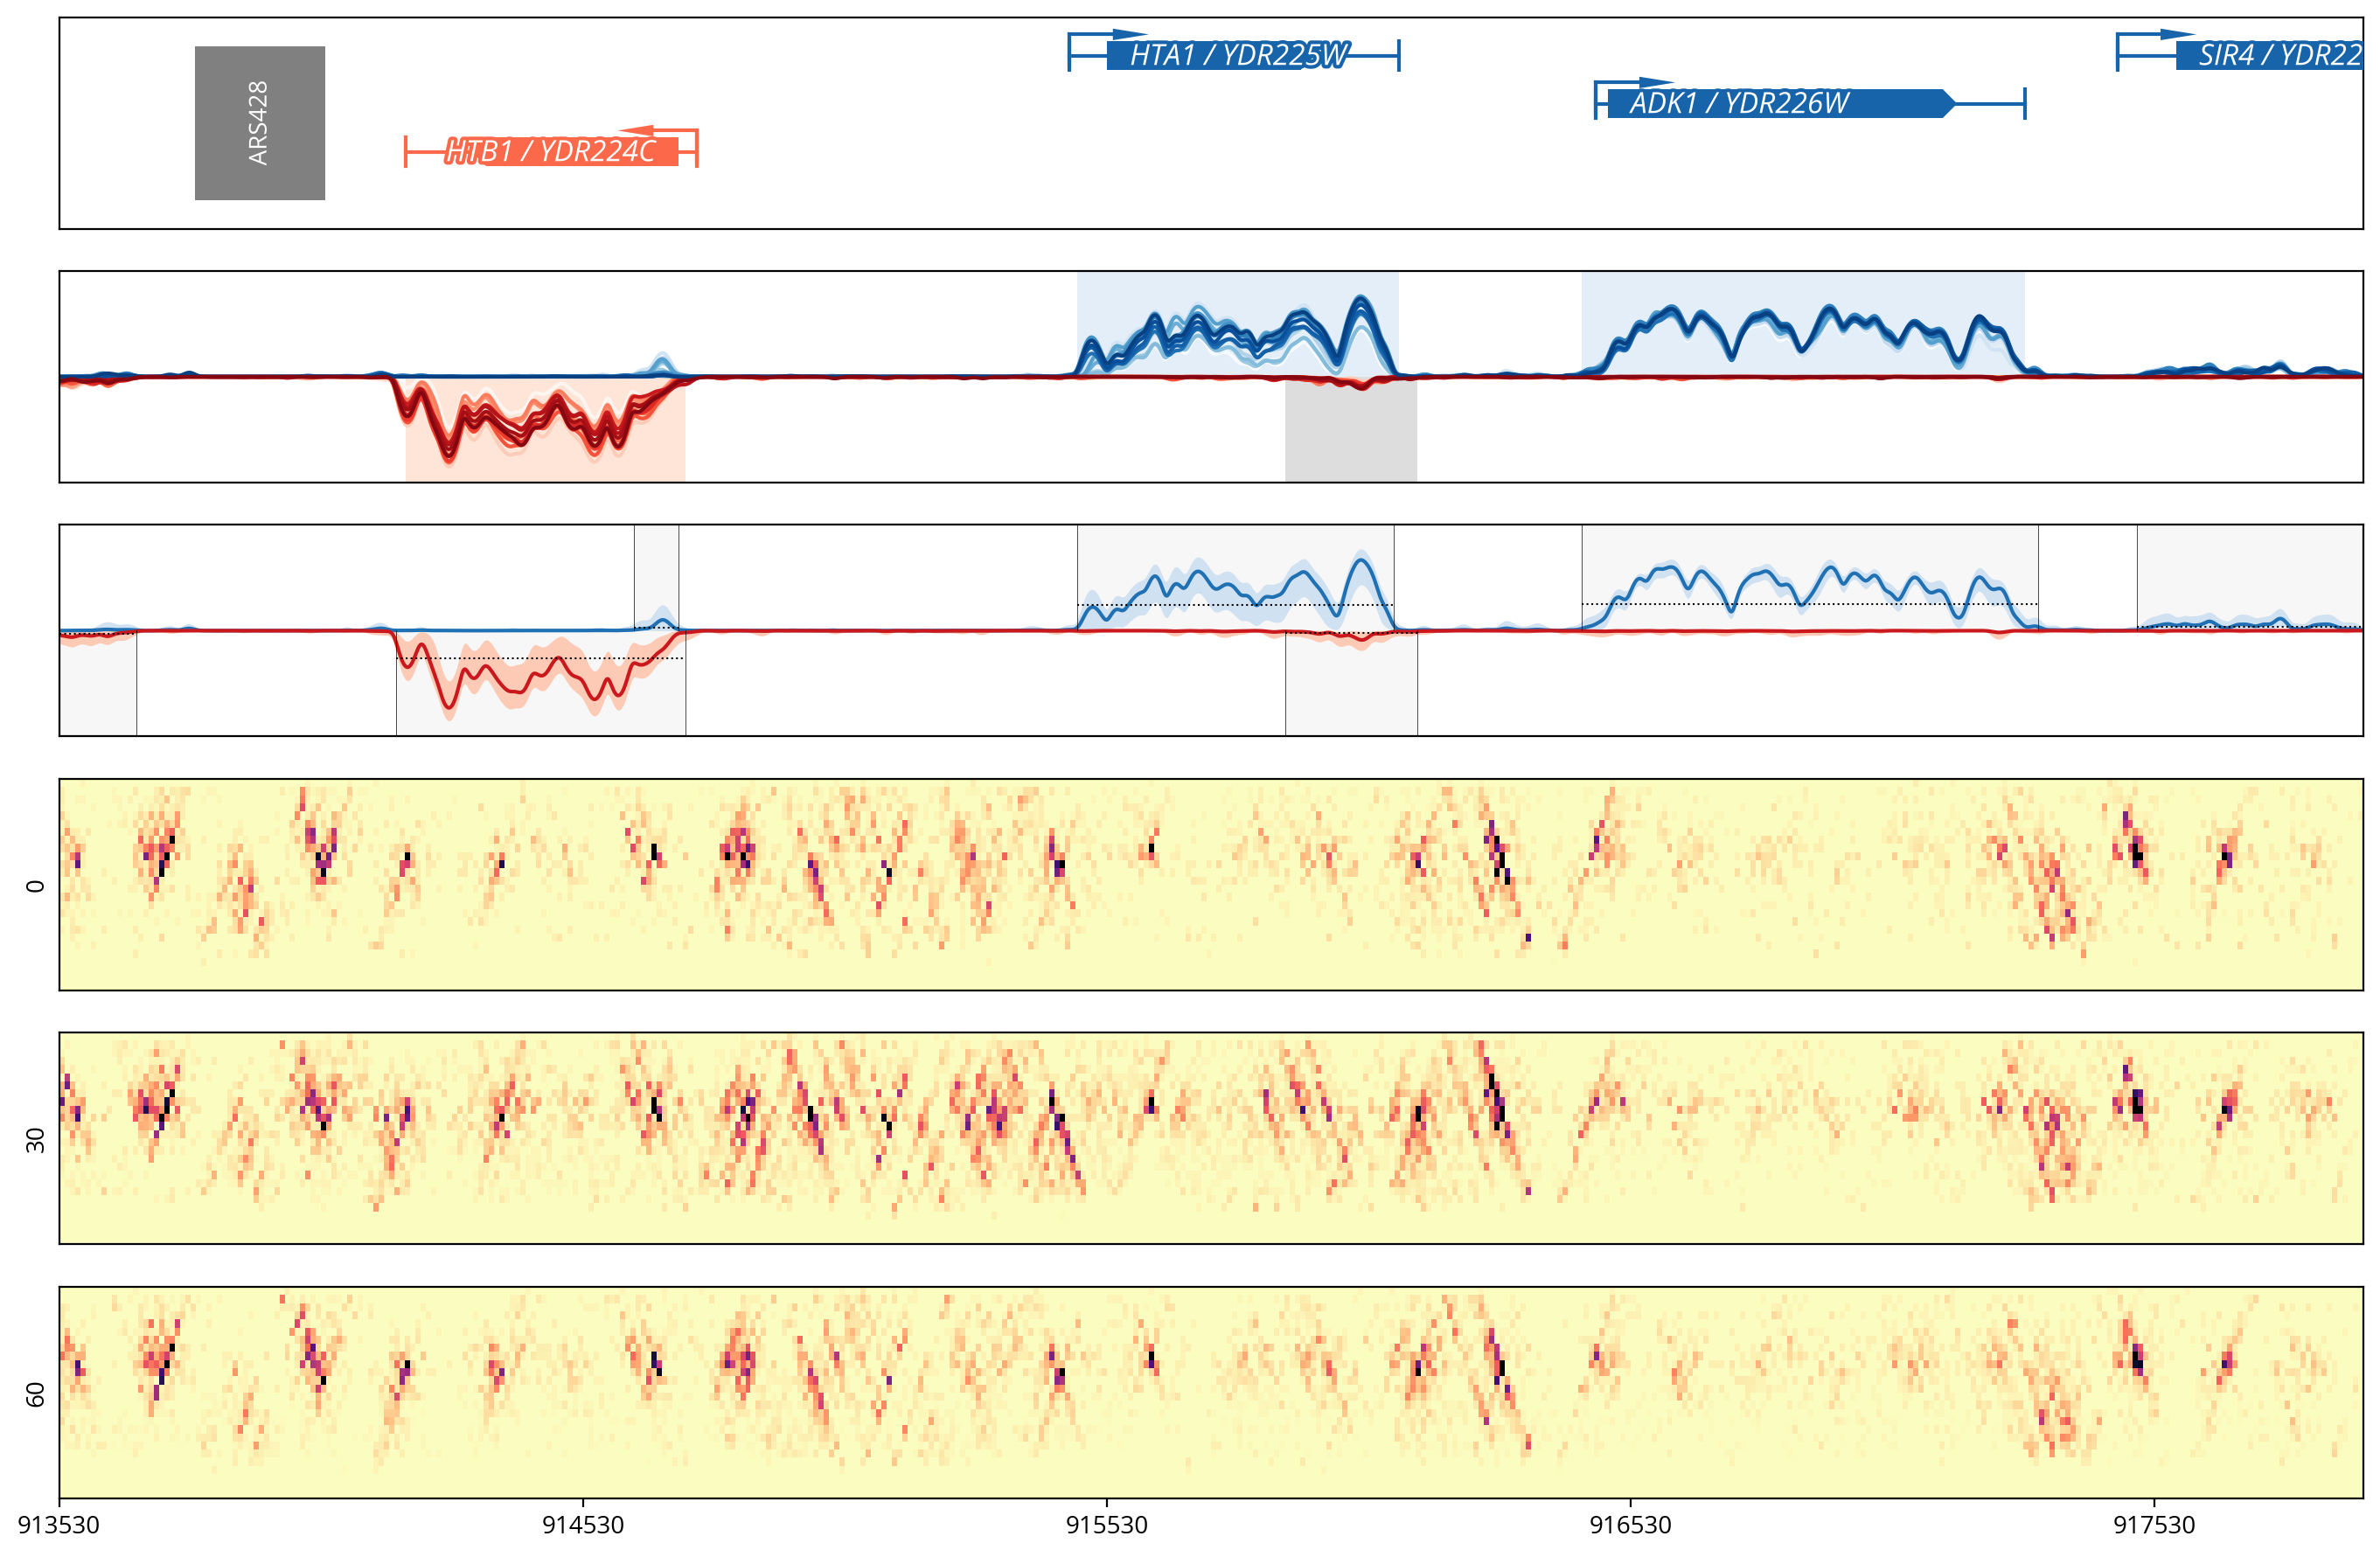

In [7]:
from src.transcript_boundary_visualizer import plot_tx_transcript_context

plot_tx_transcript_context(outdir, gene.chr, span, orf_plotter, rna_plotter, 
                           combined_model, caller)

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 4
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr4.h5, crick_rna_seq_pileup_rep1_chr4.h5
Shape: (16, 1531933) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr4.h5, crick_rna_seq_pileup_rep2_chr4.h5
Shape: (14, 1531933) (timepoints x positions)
(30, 4390)


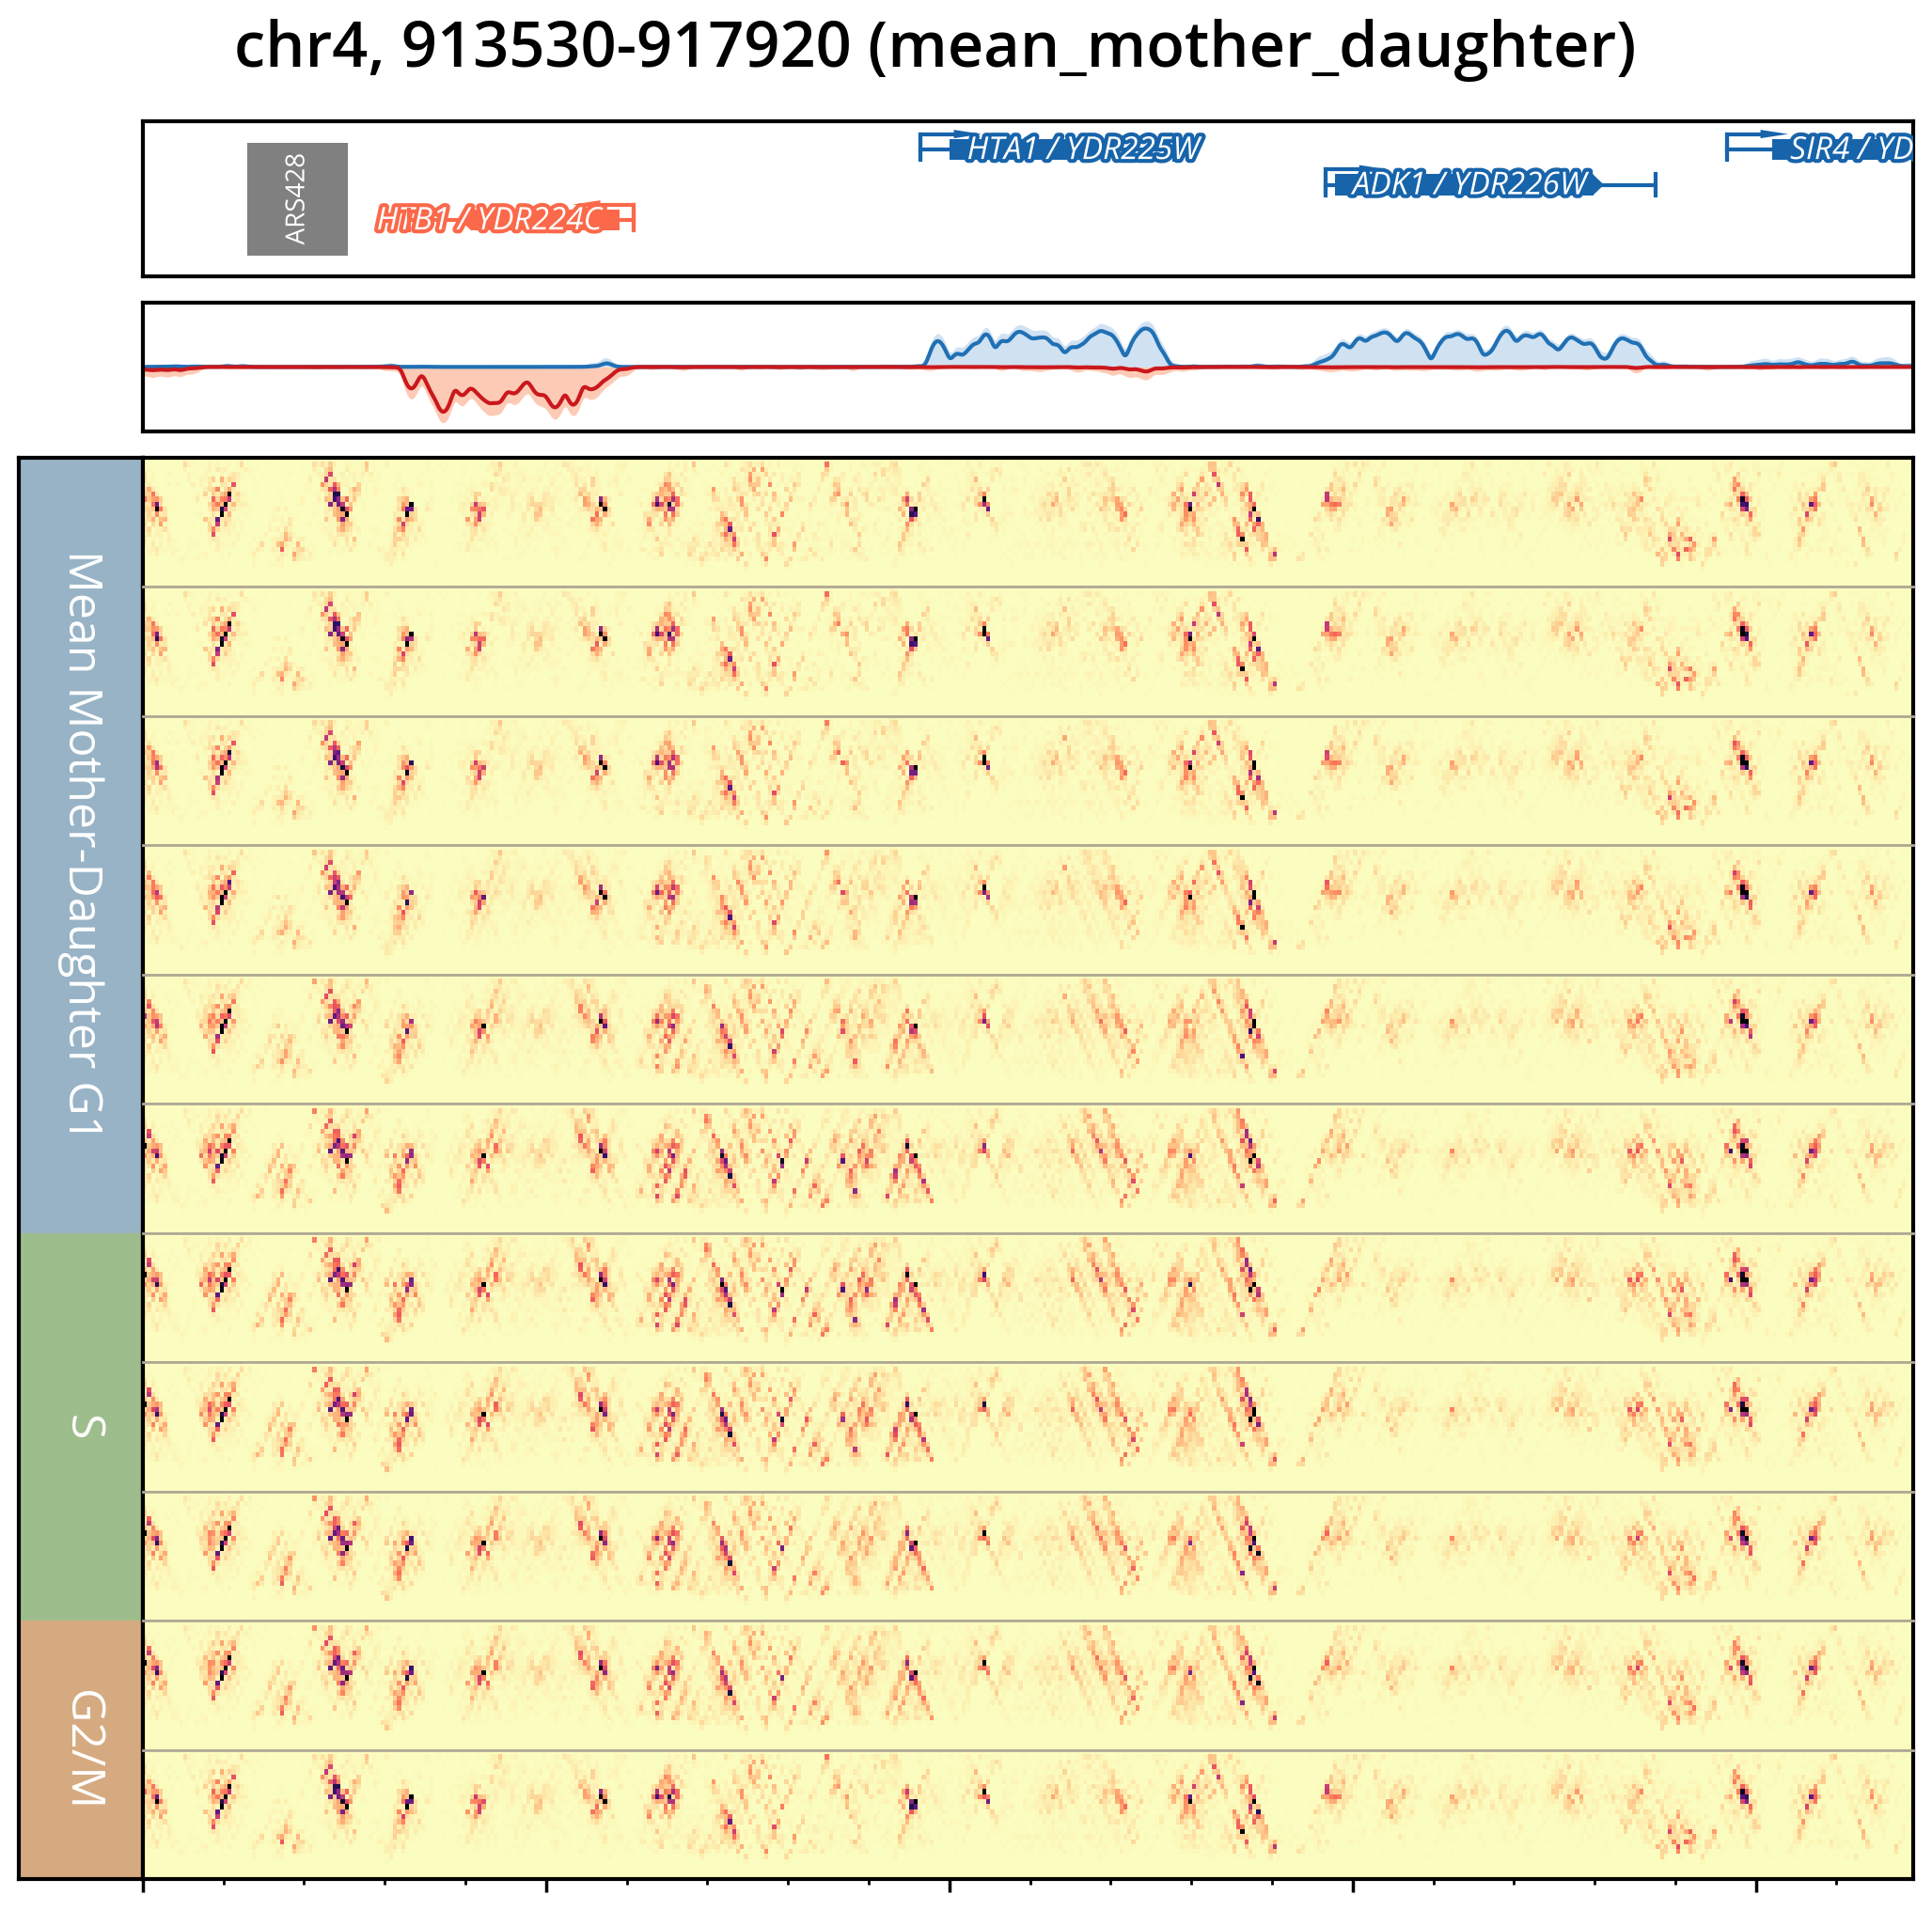

In [15]:
genome_deconv_analysis.plot_loaded_data(figsize=(13, 11))